In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/fatimafarzand/global-petrol-prices-april-2026/Petrol prices have increased.png
/kaggle/input/datasets/fatimafarzand/global-petrol-prices-april-2026/Petrol prices.xlsx
/kaggle/input/datasets/fatimafarzand/global-petrol-prices-april-2026/Fuel price.pbix


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import pandas as pd 

In [3]:
df = pd.read_excel("/kaggle/input/datasets/fatimafarzand/global-petrol-prices-april-2026/Petrol prices.xlsx")


In [4]:
df.describe()

,Price_Per_Liter_USD,Price_Per_Gallon_USD,Previous_Price_USD,Price_Change_Percent
count,101.000000,101.000000,101.000000,101.000000
mean,1.380891,5.227030,1.278911,8.030693
std,0.709434,2.685499,0.645317,14.363076
min,0.010000,0.040000,0.010000,-65.600000
25%,0.850000,3.220000,0.820000,0.000000
50%,1.310000,4.960000,1.200000,5.300000
75%,1.870000,7.080000,1.720000,12.700000
max,4.110000,15.560000,3.780000,55.100000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               101 non-null    object 
 1   Region                101 non-null    object 
 2   Price_Per_Liter_USD   101 non-null    float64
 3   Price_Per_Gallon_USD  101 non-null    float64
 4   Previous_Price_USD    101 non-null    float64
 5   Price_Change_Percent  101 non-null    float64
 6   Price_Trend           101 non-null    object 
 7   Price_Level           101 non-null    object 
dtypes: float64(4), object(4)
memory usage: 6.4+ KB


In [6]:
df.head()

,Country,Region,Price_Per_Liter_USD,Price_Per_Gallon_USD,Previous_Price_USD,Price_Change_Percent,Price_Trend,Price_Level
0,Hong Kong,Asia,4.11,15.56,3.78,8.7,Stable,Very High
1,Singapore,Asia,3.38,12.79,2.84,19.0,Rising Sharply,Very High
2,Netherlands,Europe,2.80,10.60,2.56,9.4,Stable,Very High
3,Denmark,Europe,2.54,9.61,2.26,12.4,Rising,Very High
4,Germany,Europe,2.47,9.35,2.18,13.3,Rising,Very High


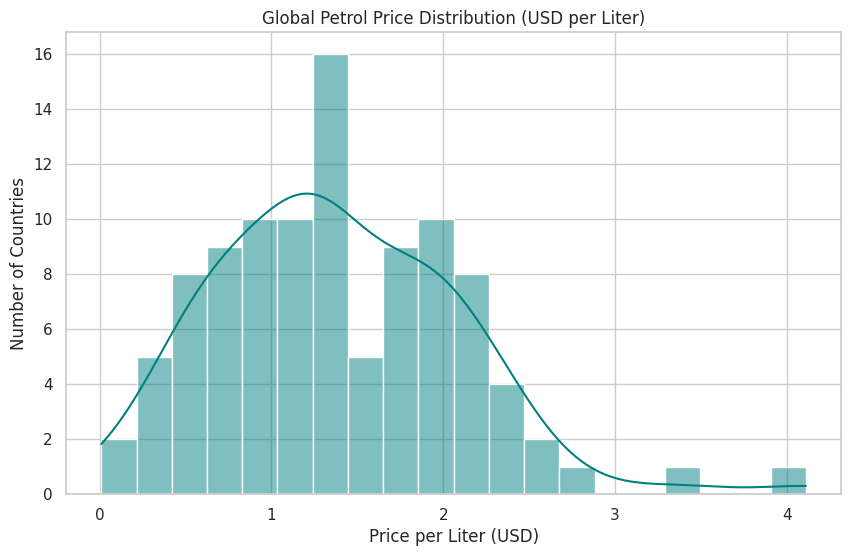

In [7]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df['Price_Per_Liter_USD'], kde=True, color='teal', bins=20)
plt.title('Global Petrol Price Distribution (USD per Liter)')
plt.xlabel('Price per Liter (USD)')
plt.ylabel('Number of Countries')
plt.show()

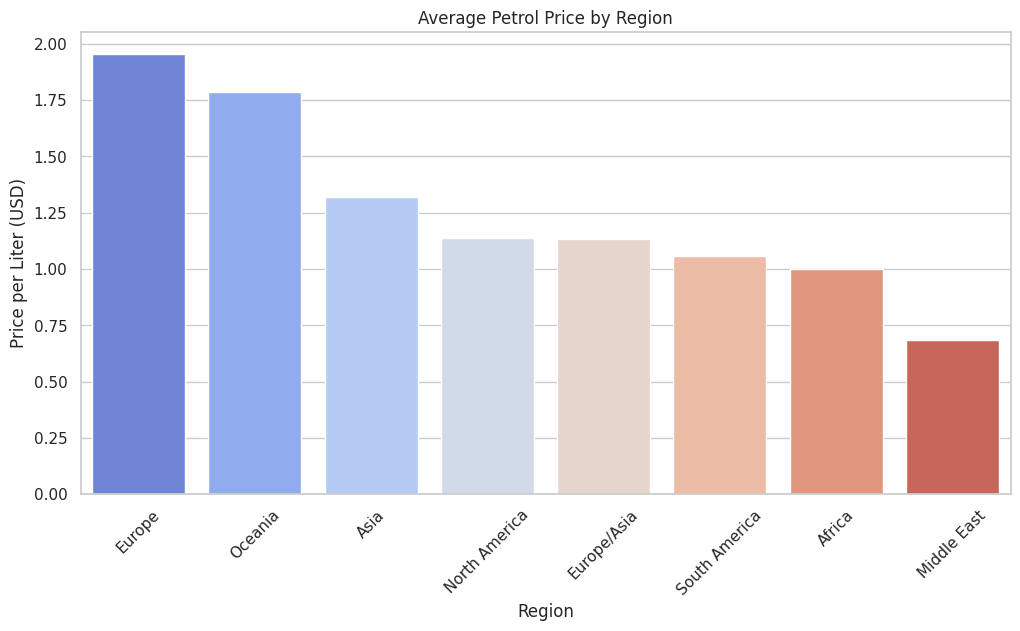

In [8]:
plt.figure(figsize=(12, 6))
region_order = df.groupby('Region')['Price_Per_Liter_USD'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='Region', y='Price_Per_Liter_USD', order=region_order, palette='coolwarm', errorbar=None)
plt.xticks(rotation=45)
plt.title('Average Petrol Price by Region')
plt.ylabel('Price per Liter (USD)')
plt.show()
# usa dolars 

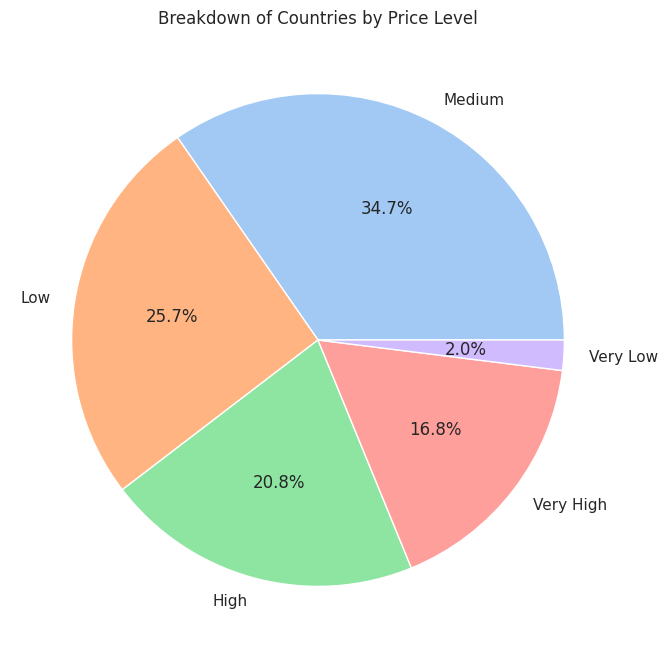

In [9]:
plt.figure(figsize=(8, 8))
price_level_counts = df['Price_Level'].value_counts()
plt.pie(price_level_counts, labels=price_level_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Breakdown of Countries by Price Level')
plt.show()


In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['float64']).corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Matrix of Price Metrics')
plt.show(

SyntaxError: incomplete input (1442385957.py, line 4)

In [ ]:
plt.figure(figsize=(10, 6))
sns.stripplot(data=df, x='Price_Level', y='Price_Change_Percent', hue='Region', jitter=True, alpha=0.6)
plt.title('Price Change Percentage across Price Levels')
plt.ylabel('Price Change (%)')
plt.show()

In [ ]:
top_15 = df.nlargest(15, 'Price_Per_Liter_USD')
plt.figure(figsize=(14, 7))
x = range(len(top_15))
plt.bar(x, top_15['Price_Per_Liter_USD'], width=0.4, label='Current Price', align='center', color='crimson')
plt.bar(x, top_15['Previous_Price_USD'], width=0.4, label='Previous Price', align='edge', color='gray', alpha=0.5)
plt.xticks(x, top_15['Country'], rotation=45)
plt.legend()
plt.title('Current vs. Previous Price for Top 15 Most Expensive Countries')
plt.ylabel('Price per Liter (USD)')
plt.show()


In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Region', hue='Price_Trend', palette='Set2')
plt.xticks(rotation=45)
plt.title('Price Trends Observed Across Regions')
plt.show()